# **Import Libraries & Setup**

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tabulate import tabulate

# **Data Acquisition and Preprocessing**

In [2]:
STOCK_TICKER = 'ADANIPOWER.NS'
START_DATE = '2023-01-01'
END_DATE = '2023-12-31'

# Download stock data
stock_data = yf.download(STOCK_TICKER, start=START_DATE, end=END_DATE, progress=False)
# Calculate daily log returns
stock_data['Log_Returns'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))
daily_returns = stock_data['Log_Returns'].dropna()

print(f"Data downloaded for {STOCK_TICKER} from {START_DATE} to {END_DATE}")
print(f"Number of trading days (and returns) calculated: {len(daily_returns)}")
print("\nDescriptive Statistics for Daily Log Returns:")
print(daily_returns.describe())

/tmp/ipython-input-2-4057376402.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(STOCK_TICKER, start=START_DATE, end=END_DATE, progress=False)


Data downloaded for ADANIPOWER.NS from 2023-01-01 to 2023-12-31
Number of trading days (and returns) calculated: 244

Descriptive Statistics for Daily Log Returns:
count    244.000000
mean       0.002320
std        0.032980
min       -0.073289
25%       -0.015492
50%       -0.002012
75%        0.020814
max        0.146745
Name: Log_Returns, dtype: float64


# **Maximum Likelihood Estimation (MLE)**

In [3]:
distributions_to_fit = {
    'Normal': stats.norm,
    'Student\'s t': stats.t,
    'Laplace': stats.laplace,
    'Logistic': stats.logistic,
    'Cauchy': stats.cauchy
}
fitted_params = {}
param_table = []

for name, distribution in distributions_to_fit.items():
    params = distribution.fit(daily_returns)
    fitted_params[name] = params

    # Format parameters for printing
    if name == 'Student\'s t':
        df, loc, scale = params
        param_str = f"df={df:.4f}, loc={loc:.4f}, scale={scale:.4f}"
    else:
        loc, scale = params
        param_str = f"loc={loc:.4f}, scale={scale:.4f}"
    param_table.append([name, param_str])

print("Fitted Parameters:")
print(tabulate(param_table, headers=['Distribution', 'Estimated Parameters'], tablefmt='grid'))
print("\n")

Fitted Parameters:
+----------------+-------------------------------------+
| Distribution   | Estimated Parameters                |
+================+=====================================+
| Normal         | loc=0.0023, scale=0.0329            |
+----------------+-------------------------------------+
| Student's t    | df=8.7941, loc=0.0015, scale=0.0289 |
+----------------+-------------------------------------+
| Laplace        | loc=-0.0020, scale=0.0249           |
+----------------+-------------------------------------+
| Logistic       | loc=0.0013, scale=0.0182            |
+----------------+-------------------------------------+
| Cauchy         | loc=-0.0016, scale=0.0171           |
+----------------+-------------------------------------+




# **Hypothesis Testing (Kolmogorov-Smirnov Test) & Visuals**

In [4]:
ks_results_list = []
scipy_dist_names = {'Normal': 'norm', 'Student\'s t': 't', 'Laplace': 'laplace', 'Logistic': 'logistic', 'Cauchy': 'cauchy'}

for name, params in fitted_params.items():
    stat, p_value = stats.kstest(daily_returns, scipy_dist_names[name], args=params)
    ks_results_list.append([name, stat, p_value])

ks_results_df = pd.DataFrame(ks_results_list, columns=['Distribution', 'KS Statistic', 'P-Value'])
ks_results_df = ks_results_df.sort_values(by='P-Value', ascending=False)

print("Kolmogorov-Smirnov Test Results (Ranked by P-Value):")
print(tabulate(ks_results_df, headers='keys', tablefmt='grid', showindex=False))

best_fit_name = ks_results_df.iloc[0]['Distribution']
print(f"\nCONCLUSION: The '{best_fit_name}' distribution provides the best fit with the highest p-value.")

Kolmogorov-Smirnov Test Results (Ranked by P-Value):
+----------------+----------------+-----------+
| Distribution   |   KS Statistic |   P-Value |
+================+================+===========+
| Student's t    |      0.0613372 | 0.30509   |
+----------------+----------------+-----------+
| Logistic       |      0.0615026 | 0.302075  |
+----------------+----------------+-----------+
| Normal         |      0.0716681 | 0.155324  |
+----------------+----------------+-----------+
| Laplace        |      0.0721945 | 0.149635  |
+----------------+----------------+-----------+
| Cauchy         |      0.0872343 | 0.0458844 |
+----------------+----------------+-----------+

CONCLUSION: The 'Student's t' distribution provides the best fit with the highest p-value.


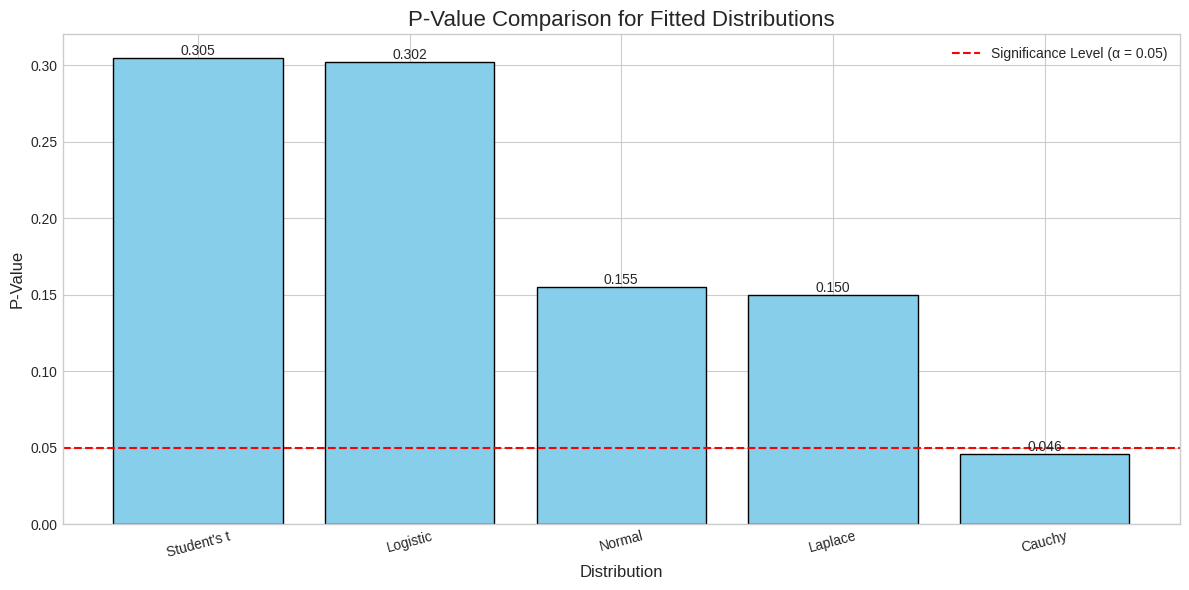

P-value comparison plot has been generated.


In [5]:
# Visualize P-Values
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))
bars = plt.bar(ks_results_df['Distribution'], ks_results_df['P-Value'], color='skyblue', edgecolor='black')
plt.axhline(y=0.05, color='red', linestyle='--', label='Significance Level (α = 0.05)')
plt.title('P-Value Comparison for Fitted Distributions', fontsize=16)
plt.xlabel('Distribution', fontsize=12)
plt.ylabel('P-Value', fontsize=12)
plt.xticks(rotation=15)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.3f}', va='bottom', ha='center')
plt.legend()
plt.tight_layout()
plt.show()
print("P-value comparison plot has been generated.")

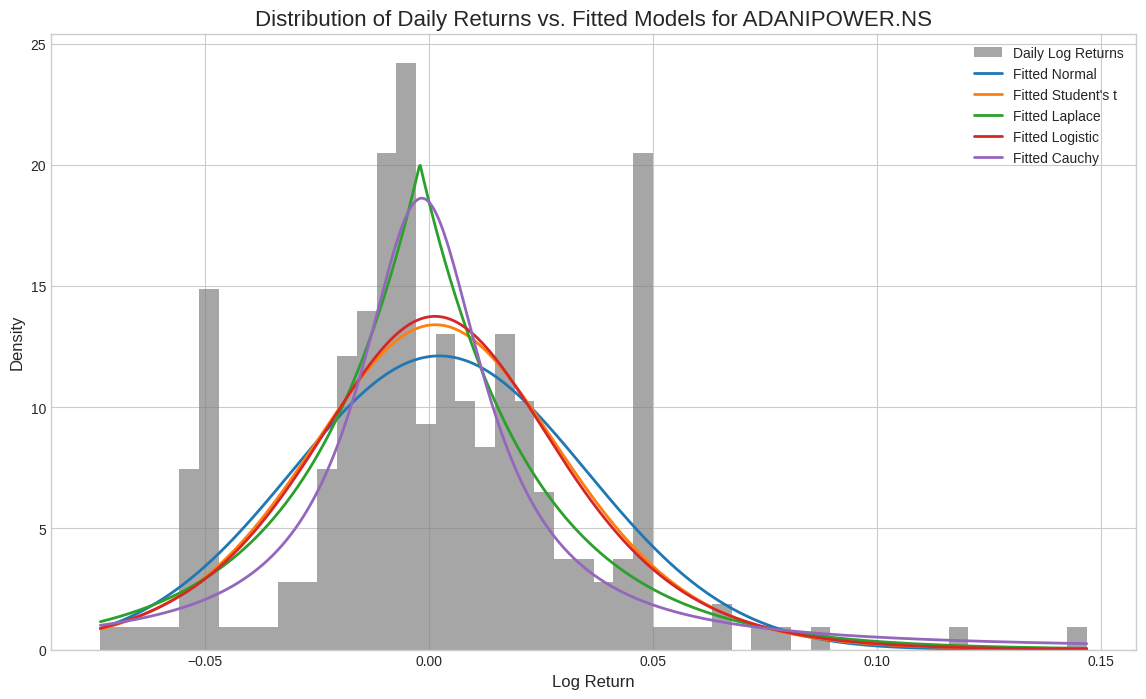

In [6]:
# Visualize Histogram with all Fitted Distributions
plt.figure(figsize=(14, 8))
plt.hist(daily_returns, bins=50, density=True, alpha=0.7, color='gray', label='Daily Log Returns')
x_axis = np.linspace(daily_returns.min(), daily_returns.max(), 1000)
for name, params in fitted_params.items():
    pdf = distributions_to_fit[name].pdf(x_axis, *params)
    plt.plot(x_axis, pdf, label=f'Fitted {name}', lw=2)
plt.title(f'Distribution of Daily Returns vs. Fitted Models for {STOCK_TICKER}', fontsize=16)
plt.xlabel('Log Return', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

# **More Diagnostic Plots**

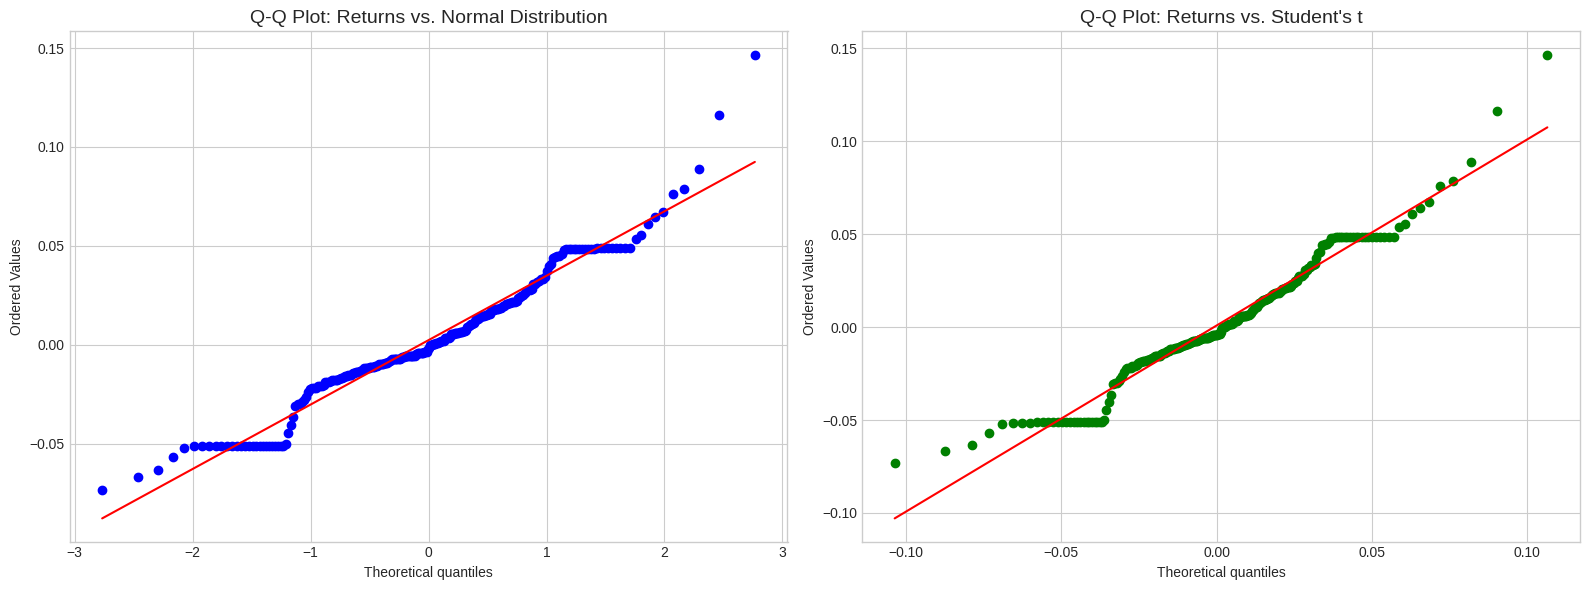

Q-Q plots have been generated.


In [9]:
# Q-Q Plots
best_fit_dist_obj = distributions_to_fit[best_fit_name]
best_fit_params = fitted_params[best_fit_name]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Q-Q plot against Normal
stats.probplot(daily_returns, dist=stats.norm, plot=ax1)
ax1.set_title('Q-Q Plot: Returns vs. Normal Distribution', fontsize=14)
ax1.get_lines()[0].set_markerfacecolor('b')
ax1.get_lines()[0].set_markeredgecolor('b')
ax1.get_lines()[1].set_color('r')

# Q-Q plot against the best-fit distribution (Student's t)
stats.probplot(daily_returns, dist=best_fit_dist_obj, sparams=best_fit_params, plot=ax2)
ax2.set_title(f'Q-Q Plot: Returns vs. {best_fit_name}', fontsize=14)
ax2.get_lines()[0].set_markerfacecolor('g')
ax2.get_lines()[0].set_markeredgecolor('g')
ax2.get_lines()[1].set_color('r')
plt.tight_layout()
plt.show()
print("Q-Q plots have been generated.")

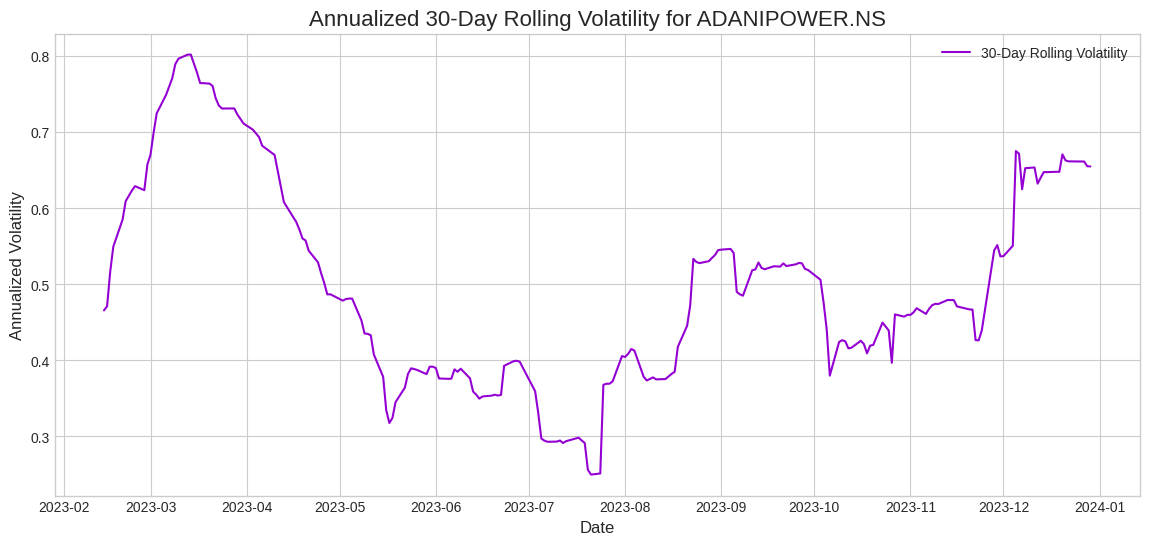

In [ ]:
# Rolling Volatility
rolling_vol = daily_returns.rolling(window=30).std() * np.sqrt(252) # Annualized
plt.figure(figsize=(14, 6))
plt.plot(rolling_vol.index, rolling_vol, label='30-Day Rolling Volatility', color='darkviolet')
plt.title(f'Annualized 30-Day Rolling Volatility for {STOCK_TICKER}', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Annualized Volatility', fontsize=12)
plt.legend()
plt.show()

# **Confidence Interval Analysis & Outlier Detection**

In [10]:
confidence_level = 0.95
lower_bound, upper_bound = best_fit_dist_obj.interval(confidence_level, *best_fit_params)

print(f"95% Confidence Interval for Daily Returns: [{lower_bound:.6f}, {upper_bound:.6f}]")

# Identify outliers
outliers = daily_returns[(daily_returns < lower_bound) | (daily_returns > upper_bound)]
print("\nOutlier Detection:")
if outliers.empty:
    print("No daily returns were found outside the 95% confidence interval.")
else:
    print(f"Found {len(outliers)} days with returns outside the confidence interval:")
    print(outliers)

95% Confidence Interval for Daily Returns: [-0.064213, 0.067119]

Outlier Detection:
Found 7 days with returns outside the confidence interval:
Date
2023-07-25    0.088988
2023-08-23   -0.073289
2023-09-11    0.076253
2023-10-23   -0.066768
2023-10-27    0.078691
2023-11-28    0.116327
2023-12-05    0.146745
Name: Log_Returns, dtype: float64


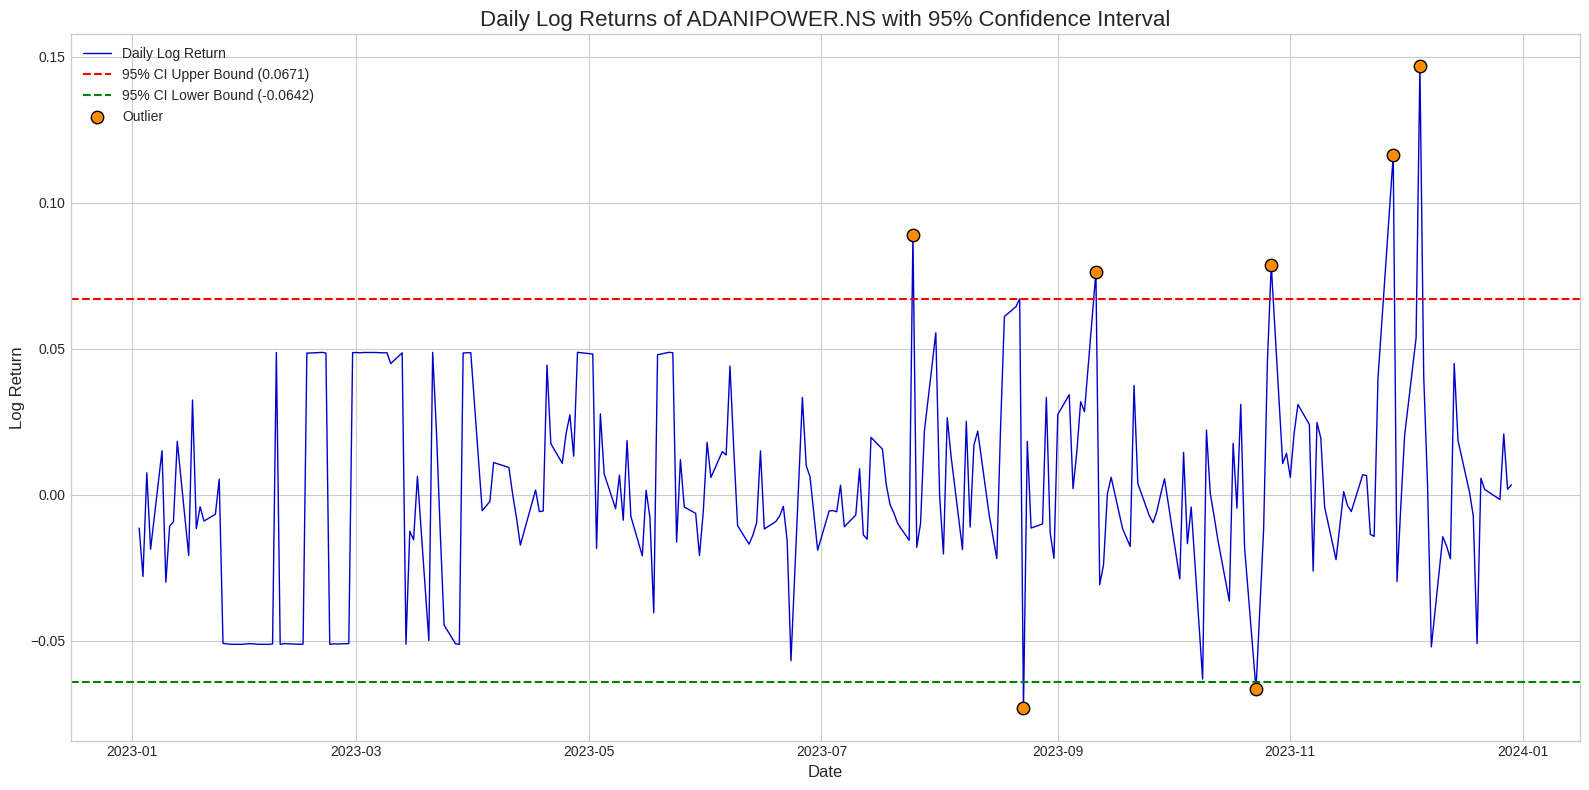

In [11]:
# Visualize Time Series with CI and Outliers
plt.figure(figsize=(16, 8))
plt.plot(daily_returns.index, daily_returns, label='Daily Log Return', color='mediumblue', lw=1.0)
plt.axhline(y=upper_bound, color='red', linestyle='--', label=f'95% CI Upper Bound ({upper_bound:.4f})')
plt.axhline(y=lower_bound, color='green', linestyle='--', label=f'95% CI Lower Bound ({lower_bound:.4f})')
plt.scatter(outliers.index, outliers, color='darkorange', s=80, zorder=5, edgecolor='black', label='Outlier')
plt.title(f'Daily Log Returns of {STOCK_TICKER} with 95% Confidence Interval', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Log Return', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()